In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve
import joblib
# Silence static "unused import" warnings without changing model logic.
_ = cross_val_score
_ = ConfusionMatrixDisplay

# Import TensorFlow only when there is a single installed build.
try:
	import tensorflow as tf
except ImportError as exc:
	raise ImportError(
		"TensorFlow is not available or there are conflicting installs. "
		"Uninstall tensorflow and tf-nightly, then install exactly one version "
		"(for example: pip uninstall -y tensorflow tf-nightly && pip install tensorflow)"
	) from exc
Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
Input = tf.keras.layers.Input
EarlyStopping = tf.keras.callbacks.EarlyStopping
print("TensorFlow version: - Bank Customer Churn.ipynb:36", tf.__version__)

TensorFlow version: - Bank Customer Churn.ipynb:36 2.16.1


In [2]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [3]:
Bank_Customer_Churn = pd.read_csv("European_Bank.csv")
Bank_Customer_Churn.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Number of rows in Bank Customer Churn dataset:", Bank_Customer_Churn.shape[0])
print("Number of columns in Bank Customer Churn dataset:", Bank_Customer_Churn.shape[1])

Number of rows in Bank Customer Churn dataset: 10000
Number of columns in Bank Customer Churn dataset: 14


In [5]:
Bank_Customer_Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
Bank_Customer_Churn.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
Bank_Customer_Churn.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
Bank_Customer_Churn.duplicated().sum()

0

In [9]:
for column in Bank_Customer_Churn.columns:
    print("\nColumn:", column)
    print(Bank_Customer_Churn[column].unique()[:10])


Column: Year
[2025]

Column: CustomerId
[15634602 15647311 15619304 15701354 15737888 15574012 15592531 15656148
 15792365 15592389]

Column: Surname
['Hargrave' 'Hill' 'Onio' 'Boni' 'Mitchell' 'Chu' 'Bartlett' 'Obinna' 'He'
 'H?']

Column: CreditScore
[619 608 502 699 850 645 822 376 501 684]

Column: Geography
['France' 'Spain' 'Germany']

Column: Gender
['Female' 'Male']

Column: Age
[42 41 39 43 44 50 29 27 31 24]

Column: Tenure
[ 2  1  8  7  4  6  3 10  5  9]

Column: Balance
[     0.    83807.86 159660.8  125510.82 113755.78 115046.74 142051.07
 134603.88 102016.72 143129.41]

Column: NumOfProducts
[1 3 2 4]

Column: HasCrCard
[1 0]

Column: IsActiveMember
[1 0]

Column: EstimatedSalary
[101348.88 112542.58 113931.57  93826.63  79084.1  149756.71  10062.8
 119346.88  74940.5   71725.73]

Column: Exited
[1 0]


In [10]:
print(Bank_Customer_Churn["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [11]:
print(Bank_Customer_Churn["Exited"].value_counts(normalize=True)*100)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


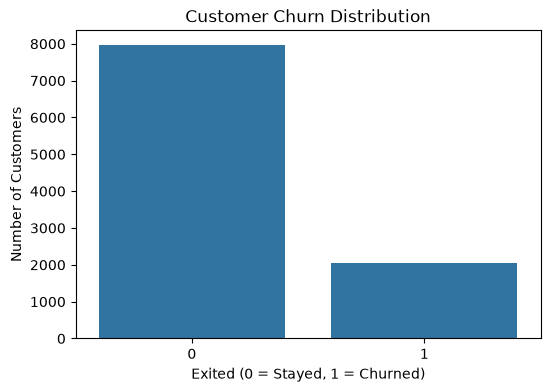

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=Bank_Customer_Churn, x="Exited")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

In [13]:
Churn_percentage = Bank_Customer_Churn["Exited"].value_counts(normalize=True)*100
print("Retained:", round(Churn_percentage[0],2), "%")
print("Churned:", round(Churn_percentage[1], 2), "%")

Retained: 79.63 %
Churned: 20.37 %


In [14]:
df_model = Bank_Customer_Churn.drop(
    columns=["CustomerId", "Surname"],
    errors="ignore"
)

print(df_model.head())

   Year  CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0  2025          619    France  Female   42       2       0.00              1   
1  2025          608     Spain  Female   41       1   83807.86              1   
2  2025          502    France  Female   42       8  159660.80              3   
3  2025          699    France  Female   39       1       0.00              2   
4  2025          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [15]:
Bank_Customer_Churn["BalanceSalaryRatio"] = (Bank_Customer_Churn["Balance"] / Bank_Customer_Churn["EstimatedSalary"] + 1 )
Bank_Customer_Churn["ProductDensity"] = (Bank_Customer_Churn["NumOfProducts"] / Bank_Customer_Churn["Tenure"] + 1 )
Bank_Customer_Churn["EngagementProduct"] = (Bank_Customer_Churn["IsActiveMember"] / Bank_Customer_Churn["NumOfProducts"] + 1 )
Bank_Customer_Churn["AgeTenureInteraction"] = (Bank_Customer_Churn["Age"] / Bank_Customer_Churn["Tenure"] + 1 )
Bank_Customer_Churn.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenureInteraction
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1.000000,1.500,2.0,22.00
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1.744677,2.000,2.0,42.00
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2.401375,1.375,1.0,6.25
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1.000000,3.000,1.0,40.00
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2.587055,1.500,2.0,22.50


In [16]:
Bank_Customer_Churn[["BalanceSalaryRatio", "ProductDensity", "EngagementProduct", "AgeTenureInteraction"]].head()

,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenureInteraction
0,1.000000,1.500,2.0,22.00
1,1.744677,2.000,2.0,42.00
2,2.401375,1.375,1.0,6.25
3,1.000000,3.000,1.0,40.00
4,2.587055,1.500,2.0,22.50


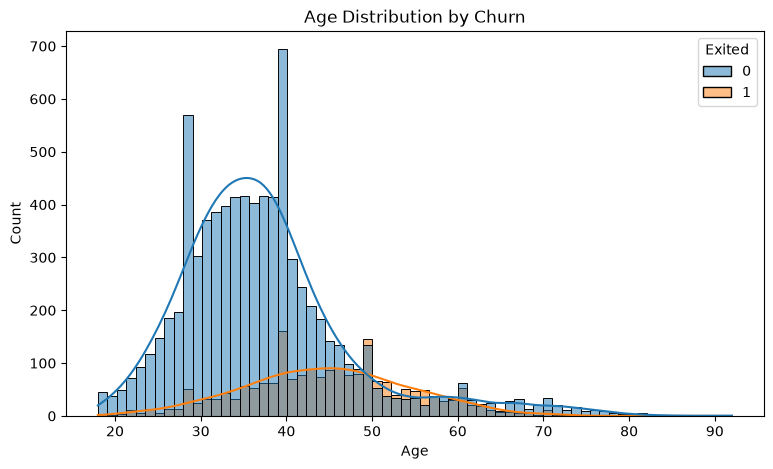

In [17]:
plt.figure(figsize=(9,5))
sns.histplot(data = Bank_Customer_Churn, x ="Age", hue = "Exited", kde = True)
plt.title("Age Distribution by Churn")
plt.show()

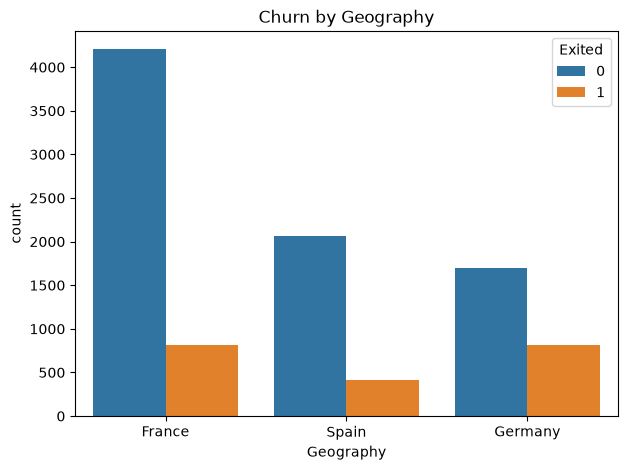

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(data = Bank_Customer_Churn, x = "Geography", hue = "Exited")
plt.title("Churn by Geography")
plt.show()

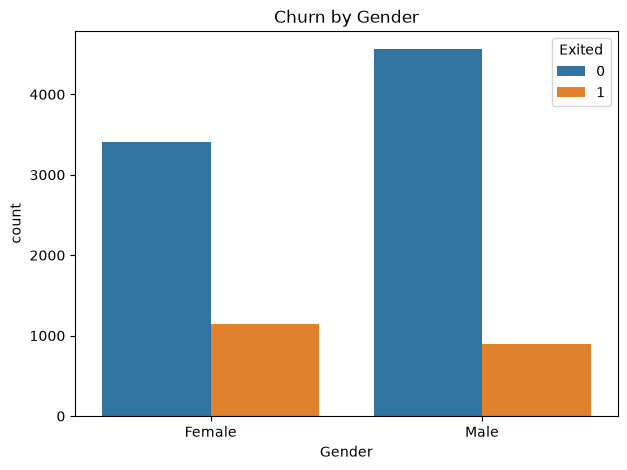

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(data = Bank_Customer_Churn, x = "Gender", hue = "Exited")
plt.title("Churn by Gender")
plt.show()

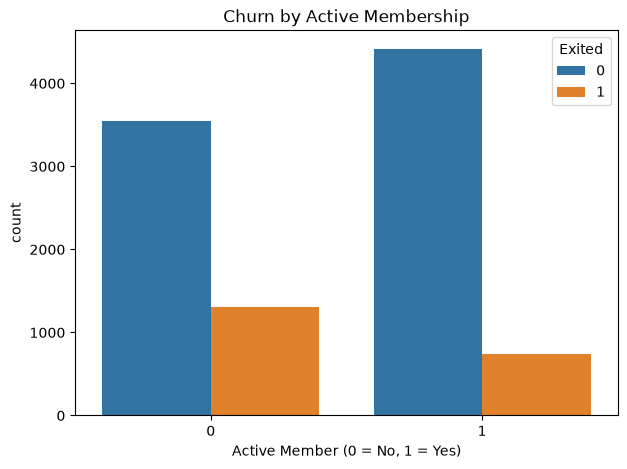

In [20]:
plt.figure(figsize=(7,5))
sns.countplot( data = Bank_Customer_Churn, x = "IsActiveMember", hue = "Exited")
plt.title("Churn by Active Membership")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.show()

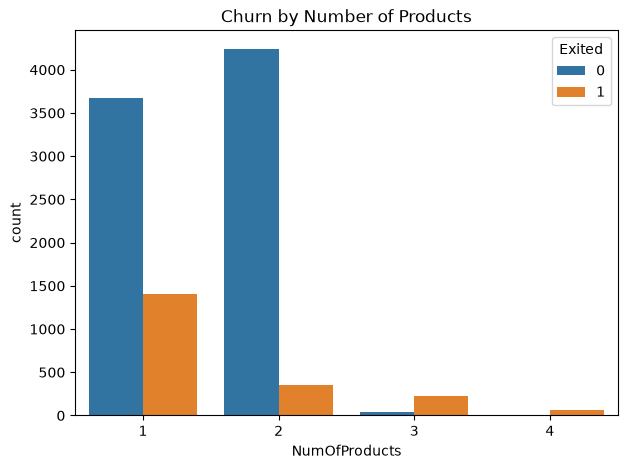

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(data = Bank_Customer_Churn, x = "NumOfProducts", hue = "Exited")
plt.title("Churn by Number of Products")
plt.show()

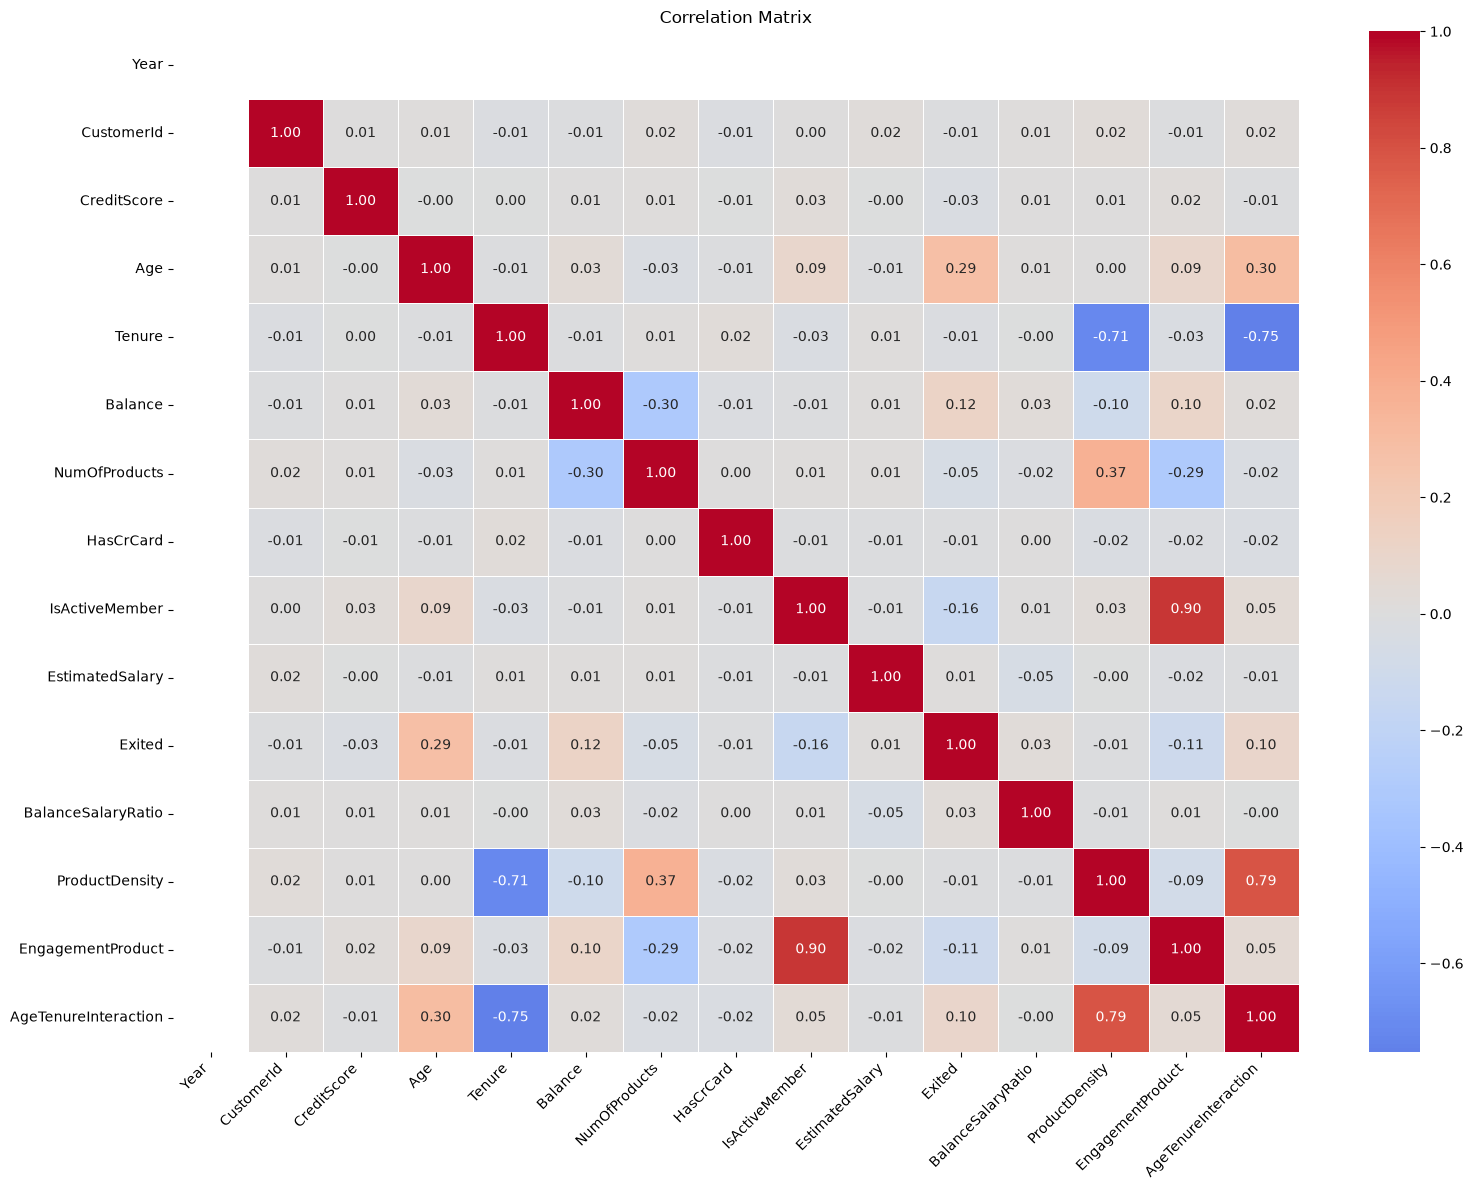

In [22]:
corr = Bank_Customer_Churn.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
x = Bank_Customer_Churn.drop("Exited", axis=1)
y = Bank_Customer_Churn["Exited"]
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (10000, 17)
y shape: (10000,)


In [24]:
categorical_columns = ["Geography","Gender"]
numerical_columns = [column 
                     for column in x.columns
                     if column not in categorical_columns
]
print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)


Categorical columns:
['Geography', 'Gender']

Numerical columns:
['Year', 'CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProduct', 'AgeTenureInteraction']


In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [26]:
print("Training data:", x_train.shape)
print("\nTesting data:", x_test.shape)

Training data: (8000, 17)

Testing data: (2000, 17)


In [27]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", 
     SimpleImputer(strategy="median")
     ),
     ("scaler", StandardScaler())])
categorical_pipeline = Pipeline(steps=[(
    "imputer",
    SimpleImputer(strategy="most_frequent")
),
("encoder",
 OneHotEncoder(handle_unknown="ignore",
               sparse_output=False))

])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numerical_pipeline,
            numerical_columns
        ),
        ("categorical",
         categorical_pipeline,
         categorical_columns)])

In [28]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor",
        preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=1000, class_weight="balanced")

)
    ]
)
x_train = x_train.drop(columns=["CustomerId", "Surname"], errors="ignore")
x_test = x_test.drop(columns=["CustomerId", "Surname"], errors="ignore")

x_train = x_train.replace([np.inf, -np.inf], np.nan)
x_test = x_test.replace([np.inf, -np.inf], np.nan)

categorical_columns = ["Geography", "Gender"]
numerical_columns = [
    column for column in x_train.columns
    if column not in categorical_columns
]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numerical_pipeline, numerical_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ]
)

logistic_model.set_params(preprocessor=preprocessor)
logistic_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementProduct',
                                                   'AgeTenureInteraction']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [29]:
decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

decision_tree_model.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementProduct',
                                                   'AgeTenureInteraction']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        random_state=42))])

In [30]:
random_forest_model = Pipeline(steps=
                               [
                                   (
                                       "preprocessor",
                                       preprocessor
                                   ),
                                   (
                                       "classifier",
                                       RandomForestClassifier(
                                           n_estimators=300,
                                           max_depth=10,
                                           random_state=42,
                                           class_weight="balanced",
                                           n_jobs=-1
                                           )
                                       )
                                   
                               ])
random_forest_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementProduct',
                                                   'AgeTenureInteraction']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [31]:
gradient_boosting_model = Pipeline(steps=[("preprocessor", preprocessor),
                                          ("classifier",
                                           GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))]
                                   )
gradient_boosting_model.fit(x_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementProduct',
                                                   'AgeTenureInteraction']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [32]:
def evaluate_model(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    y_probability = model.predict_proba(x_test)[:,1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [33]:
results = []
results.append(evaluate_model(logistic_model, x_test, y_test, "LogisticRegression"))
results.append(evaluate_model(decision_tree_model, x_test, y_test, "DecisionTreeClassifier"))
results.append(evaluate_model(random_forest_model, x_test, y_test, "RandomForestClassifier"))
results.append(evaluate_model(gradient_boosting_model, x_test, y_test, "GradientBoostingClassifier"))
results_df = pd.DataFrame(results)

In [34]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LogisticRegression,0.719,0.394844,0.714988,0.508741,0.717506
1,DecisionTreeClassifier,0.760,0.448227,0.776413,0.568345,0.766110
2,RandomForestClassifier,0.841,0.603730,0.636364,0.619617,0.764823
3,GradientBoostingClassifier,0.866,0.772549,0.484029,0.595166,0.723810


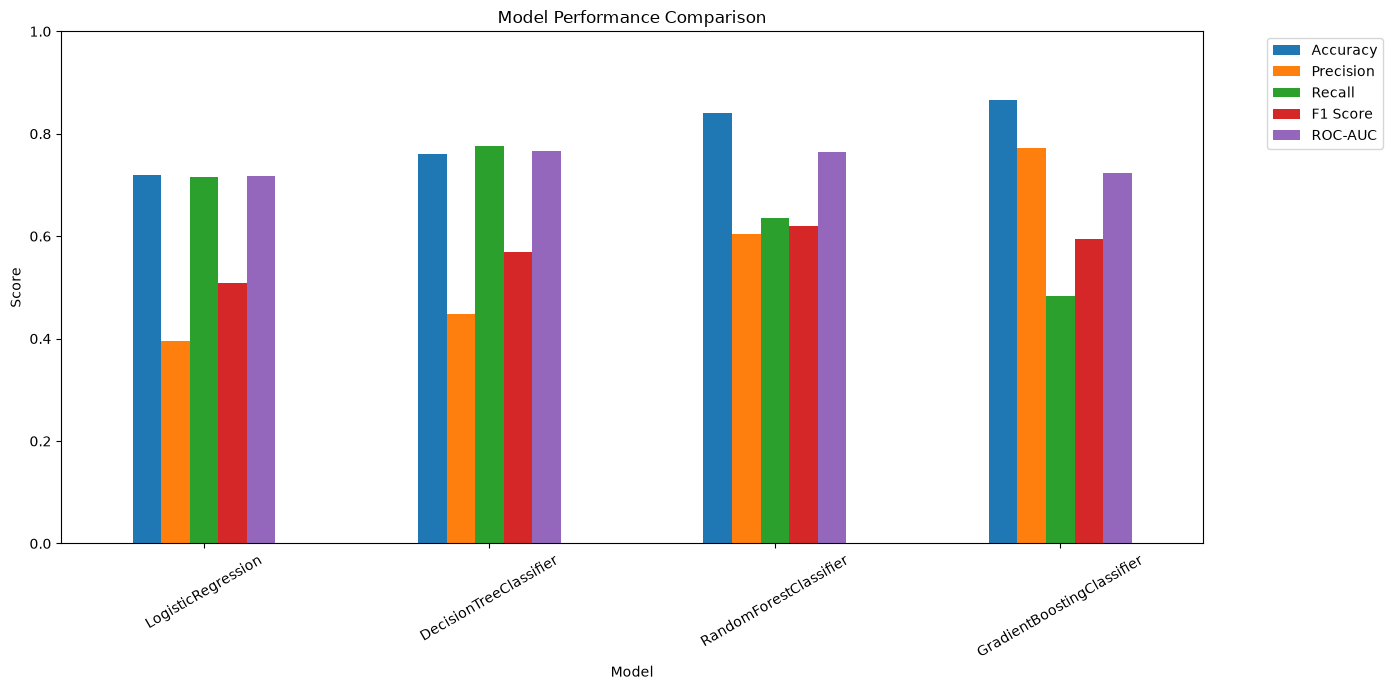

In [35]:
results_plot = results_df.set_index("Model")

results_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [36]:
best_ml_model_name = results_df.loc[results_df["ROC-AUC"].idxmax(),"Model"]
print("Best ML model based on ROC-AUC:")
print(best_ml_model_name)

Best ML model based on ROC-AUC:
DecisionTreeClassifier


In [37]:
rf_predictions = random_forest_model.predict(x_test)
print(classification_report(y_test,rf_predictions))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.60      0.64      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



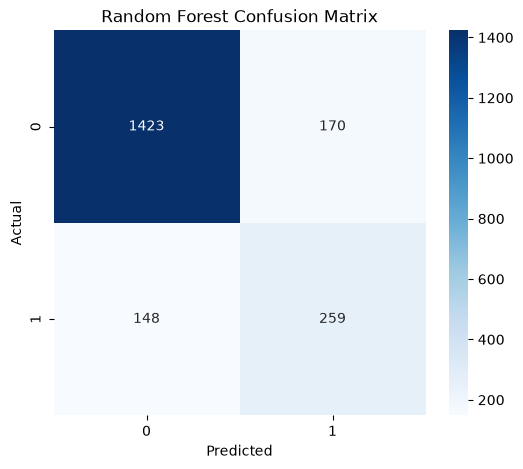

In [38]:
rf_cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

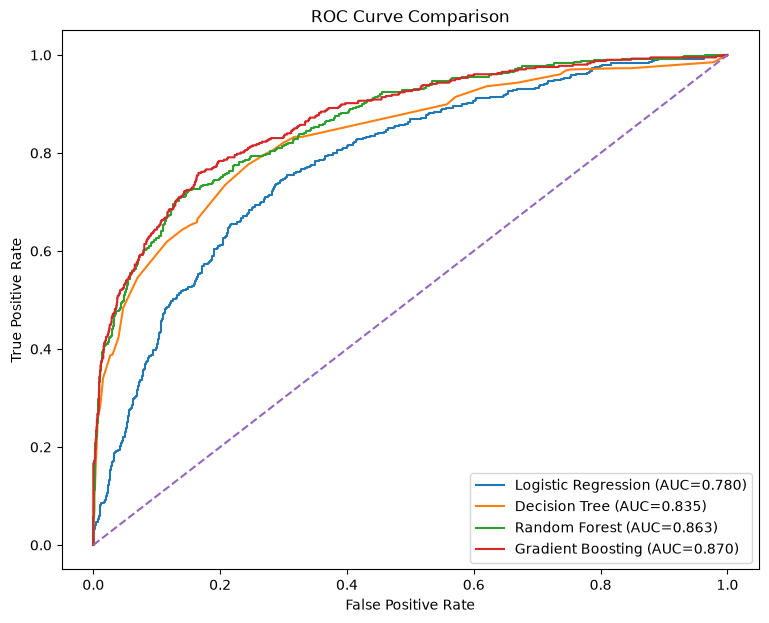

In [39]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

plt.figure(figsize=(9, 7))

for name, model in models.items():

    probability = model.predict_proba(x_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc_score = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [40]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]
feature_names = (rf_preprocessor.get_feature_names_out())
importance = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance_df.head(15)

,Feature,Importance
2,numeric__Age,0.260167
5,numeric__NumOfProducts,0.150830
4,numeric__Balance,0.082272
12,numeric__AgeTenureInteraction,0.071877
11,numeric__EngagementProduct,0.068693
9,numeric__BalanceSalaryRatio,0.062480
8,numeric__EstimatedSalary,0.058967
1,numeric__CreditScore,0.057478
10,numeric__ProductDensity,0.044139
14,categorical__Geography_Germany,0.035418


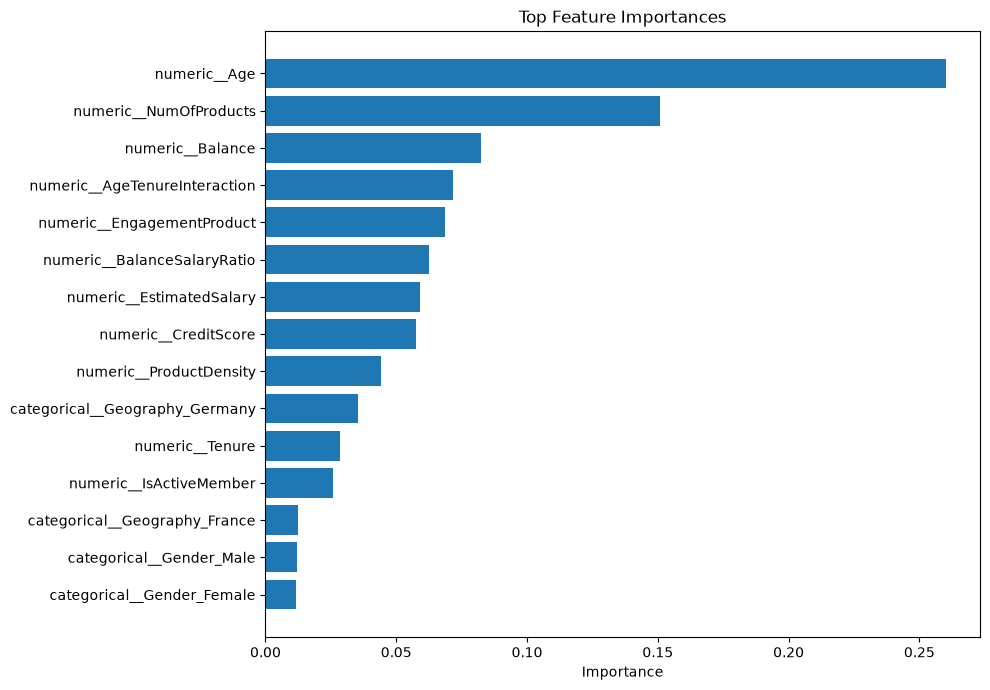

In [41]:
top_features = (feature_importance_df.head(15).sort_values("Importance"))
plt.figure(figsize=(10,7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [42]:
deep_df = Bank_Customer_Churn.copy()

deep_df = pd.get_dummies(
    deep_df,
    columns=["Geography", "Gender"],
    drop_first=True
)

print(deep_df.head())
print(deep_df.dtypes)

   Year  CustomerId   Surname  CreditScore  Age  Tenure    Balance  \
0  2025    15634602  Hargrave          619   42       2       0.00   
1  2025    15647311      Hill          608   41       1   83807.86   
2  2025    15619304      Onio          502   42       8  159660.80   
3  2025    15701354      Boni          699   39       1       0.00   
4  2025    15737888  Mitchell          850   43       2  125510.82   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  \
0              1          1               1        101348.88       1   
1              1          0               1        112542.58       0   
2              3          1               0        113931.57       1   
3              2          0               0         93826.63       0   
4              1          1               1         79084.10       0   

   BalanceSalaryRatio  ProductDensity  EngagementProduct  \
0            1.000000           1.500                2.0   
1            1.744677     

In [43]:
X_dl = deep_df.drop("Exited",axis=1)
y_dl = deep_df["Exited"]
print("X:", X_dl.shape)
print("\ny:", y_dl.shape)

X: (10000, 18)

y: (10000,)


In [44]:
feature_columns = X_dl.columns.tolist()
joblib.dump(feature_columns,"models/feature_columns.pkl")
print("feature columns saved.")

feature columns saved.


In [45]:
X_train_dl, X_test_dl,  y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size = 0.20, random_state=42, stratify=y_dl)
print(X_train_dl.shape)
print(X_test_dl.shape)

(8000, 18)
(2000, 18)


In [46]:
scaler = StandardScaler()
X_train_dl = X_train_dl.drop(columns=["CustomerId", "Surname"], errors="ignore")
X_test_dl = X_test_dl.drop(columns=["CustomerId", "Surname"], errors="ignore")

combined_dl = pd.concat([X_train_dl, X_test_dl])
categorical_dl = combined_dl.select_dtypes(
    include=["object", "category"]
).columns

combined_dl = pd.get_dummies(
    combined_dl,
    columns=categorical_dl,
    drop_first=True
)

X_train_dl = combined_dl.iloc[:len(X_train_dl)].copy()
X_test_dl = combined_dl.iloc[len(X_train_dl):].copy()

X_train_dl = X_train_dl.apply(pd.to_numeric, errors="coerce")
X_test_dl = X_test_dl.apply(pd.to_numeric, errors="coerce")

X_train_dl = X_train_dl.fillna(X_train_dl.median())
X_test_dl = X_test_dl.fillna(X_train_dl.median())

scaler = StandardScaler()
X_train_dl = X_train_dl.replace([np.inf, -np.inf], np.nan)
X_test_dl = X_test_dl.replace([np.inf, -np.inf], np.nan)

train_medians = X_train_dl.median()
X_train_dl = X_train_dl.fillna(train_medians)
X_test_dl = X_test_dl.fillna(train_medians)

X_train_scaled = scaler.fit_transform(X_train_dl)
X_test_scaled = scaler.transform(X_test_dl)

In [47]:
joblib.dump(
    scaler,
    "models/churn_scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [48]:
tf.random.set_seed(42)
deep_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [49]:
deep_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
deep_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [51]:
early_stopping = EarlyStopping(monitor="val_loss",
                               patience=10,
                               restore_best_weights=True
                               )

In [52]:
history = deep_model.fit(X_train_scaled, y_train_dl,
                         validation_split=0.20,
                         epochs=100,
                         batch_size=32,
                         callbacks=[early_stopping],
                         verbose=1
                         )

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7808 - auc: 0.6257 - loss: 0.5038 - val_accuracy: 0.8056 - val_auc: 0.7593 - val_loss: 0.4313
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8075 - auc: 0.7653 - loss: 0.4320 - val_accuracy: 0.8331 - val_auc: 0.8010 - val_loss: 0.4000
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8211 - auc: 0.7965 - loss: 0.4081 - val_accuracy: 0.8531 - val_auc: 0.8315 - val_loss: 0.3739
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8359 - auc: 0.8050 - loss: 0.3972 - val_accuracy: 0.8631 - val_auc: 0.8432 - val_loss: 0.3588
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8353 - auc: 0.8201 - loss: 0.3839 - val_accuracy: 0.8662 - val_auc: 0.8488 - val_loss: 0.3523
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8403 - auc: 0.8269 - loss: 0.3789 - val_accuracy: 0.8625 - val_auc: 0.8557 - val_loss: 0.3448
Epoch 7/100
200/200 ━━━━━━━━━━━━━

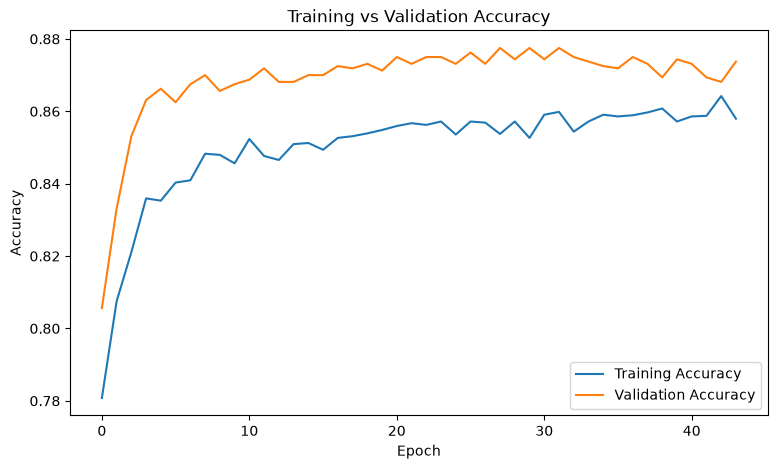

In [53]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

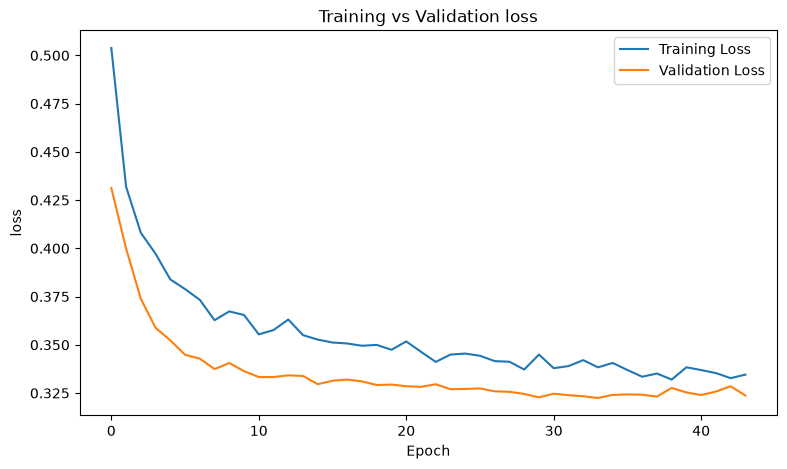

In [54]:
plt.figure(figsize = (9,5))
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [55]:
deep_results = deep_model.evaluate(X_test_scaled, y_test_dl, verbose=0)
print("Test Loss:", deep_results[0])
print("\nTest Accuracy:", deep_results[1])
print("\nTest AUC:", deep_results[2])

Test Loss: 0.341933935880661

Test Accuracy: 0.8634999990463257

Test AUC: 0.8574467897415161


In [56]:
dl_probability =(deep_model.predict(X_test_scaled, verbose=0).ravel())
dl_prediction = (dl_probability >=0.5).astype(int)

In [57]:
dl_accuracy = accuracy_score(y_test_dl, dl_prediction)
print("Accuracy :", dl_accuracy)

Accuracy : 0.8635


In [58]:
dl_precision  = precision_score(y_test_dl, dl_prediction, zero_division=0)
print("Precision:", dl_precision )


Precision: 0.7964601769911505


In [59]:
dl_recall = recall_score(y_test_dl, dl_prediction, zero_division=0)
print("Recall   :", dl_recall)

Recall   : 0.44226044226044225


In [60]:
dl_f1 = f1_score(y_test_dl, dl_prediction, zero_division=0)
print("F1 Score :", dl_f1)

F1 Score : 0.5687203791469194


In [61]:
dl_auc = roc_auc_score(y_test_dl, dl_probability)
print("ROC-AUC  :", dl_auc)

ROC-AUC  : 0.8575015693659762


In [62]:
print(classification_report(y_test_dl, dl_prediction))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.80      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



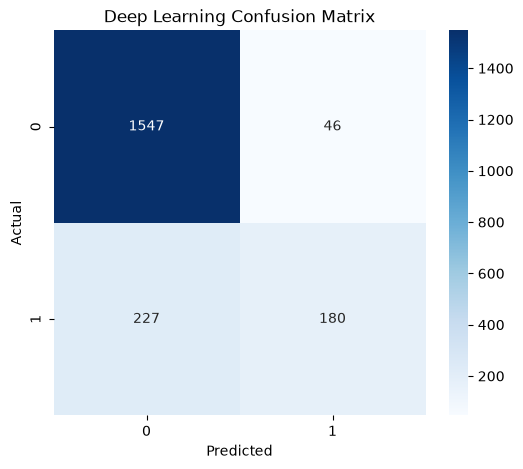

In [63]:
dl_cm = confusion_matrix(
    y_test_dl,
    dl_prediction
)
plt.figure(figsize=(6, 5))
sns.heatmap(
    dl_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Deep Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

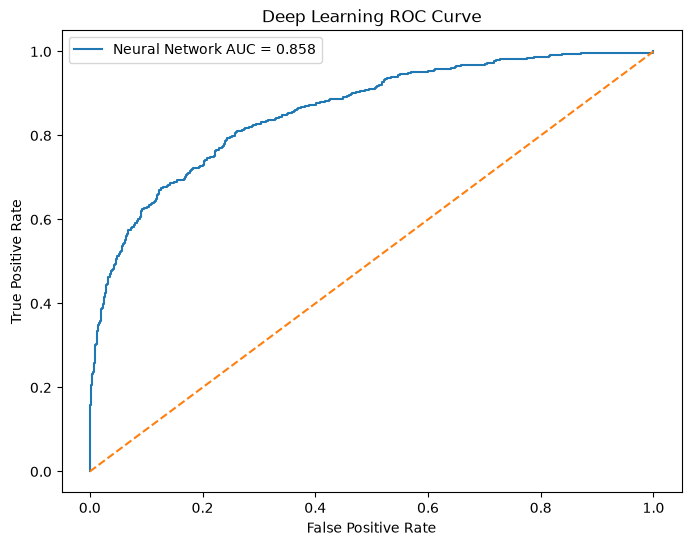

In [64]:
fpr, tpr, _ = roc_curve(
    y_test_dl,
    dl_probability
)
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Neural Network AUC = {dl_auc:.3f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Deep Learning ROC Curve")
plt.legend()
plt.show()

In [65]:
risk_scores = dl_probability * 100
def get_risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    elif probability <0.80:
        return "High"
    else:
        return "Very High"

In [66]:
prediction_results = X_test_dl.copy()
prediction_results["Actual_Exited"] = (y_test_dl.values)
prediction_results["Churn_Probability"] = (dl_probability)
prediction_results["Risk_Scores"] = (risk_scores)
prediction_results["Risk_Level"] = [get_risk_level(prob)
                                    for prob in dl_probability]
prediction_results["Predicted_Exited"] = (dl_prediction)
prediction_results.head()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,...,EngagementProduct,AgeTenureInteraction,Geography_Germany,Geography_Spain,Gender_Male,Actual_Exited,Churn_Probability,Risk_Scores,Risk_Level,Predicted_Exited
5702,2025,585,36,7,0.00,2,1,0,94283.09,1.000000,...,1.0,6.142857,False,False,True,0,0.018232,1.823171,Low,0
3667,2025,525,33,4,131023.76,2,0,0,55072.93,3.379096,...,1.0,9.250000,True,False,True,0,0.054855,5.485488,Low,0
1617,2025,557,40,4,0.00,2,0,1,105433.53,1.000000,...,1.5,11.000000,False,True,False,0,0.045910,4.591024,Low,0
5673,2025,639,34,5,139393.19,2,0,0,33950.08,5.105828,...,1.0,7.800000,False,True,True,0,0.049545,4.954538,Low,0
4272,2025,640,34,3,77826.80,1,1,1,168544.85,1.461757,...,2.0,12.333333,False,True,False,0,0.139869,13.986932,Low,0


In [67]:
prediction_results.to_csv("outputs/churn_predictions.csv",
                          index=False)
print("Predictions saved to outputs/churn_predictions.csv")

Predictions saved to outputs/churn_predictions.csv


In [68]:
print(prediction_results["Risk_Level"].value_counts())

Risk_Level
Low          1535
Medium        305
Very High      89
High           71
Name: count, dtype: int64


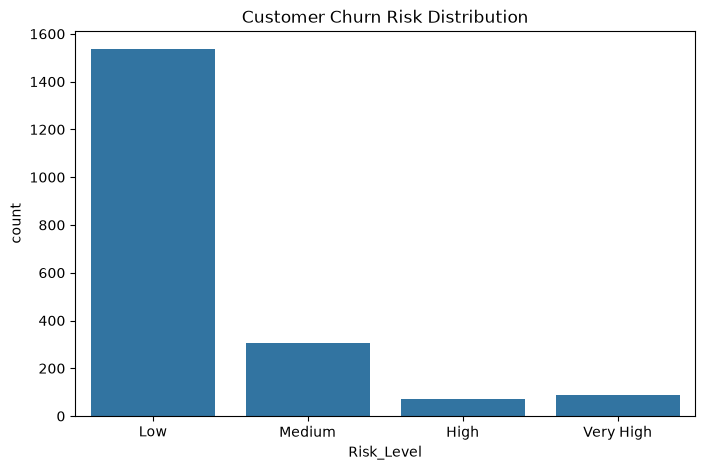

In [69]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=prediction_results,
    x="Risk_Level",
    order=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

plt.title("Customer Churn Risk Distribution")

plt.show()

In [70]:
deep_model.save("models/bank_churn_deep_learning.keras")
print("Deep learning model saved.")

Deep learning model saved.


In [71]:
deep_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score": [
        dl_accuracy,
        dl_precision,
        dl_recall,
        dl_f1,
        dl_auc
    ]
})

deep_metrics

,Metric,Score
0,Accuracy,0.863500
1,Precision,0.796460
2,Recall,0.442260
3,F1 Score,0.568720
4,ROC-AUC,0.857502


In [72]:
deep_metrics.to_csv(
    "outputs/deep_learning_metrics.csv",
    index=False
)

In [73]:
customer = pd.DataFrame({
    "CreditScore" : [650],
    "Geography": ["Germany"],
    "Gender": ["Male"],
    "Age": [40],
    "Tenure": [5],
    "Balance": [60000],
    "NumOfProducts": [2],
    "HasCrCard": [1],
    "IsActiveMember": [1],
    "EstimatedSalary": [80000]
})

In [74]:
customer["BalanceSalaryRatio"] = (
    customer["Balance"]/
    (customer["EstimatedSalary"]+1))
customer["ProductDensity"] = (
    customer["NumOfProducts"]/
    (customer["Tenure"]+1))
customer["EngagementProduct"] = (
    customer["IsActiveMember"] *
    (customer["NumOfProducts"]))
customer["AgeTenureInteraction"] = (
    customer["Age"] *
    customer["Tenure"]
)


In [75]:
customer_encoded = pd.get_dummies(customer,
                                  columns=["Geography", "Gender"],
                                  drop_first=True)

In [76]:
customer_encoded = customer_encoded.reindex(columns=feature_columns,fill_value=0)
customer_encoded

,Year,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenureInteraction,Geography_Germany,Geography_Spain,Gender_Male
0,0,0,0,650,40,5,60000,2,1,1,80000,0.749991,0.333333,2,200,0,0,0


In [77]:
customer_encoded = pd.get_dummies(
    customer,
    columns=["Geography", "Gender"],
    drop_first=True
)

customer_encoded = customer_encoded.drop(columns=["CustomerId", "Surname"], errors="ignore")

expected_cols = list(scaler.feature_names_in_)
customer_encoded = customer_encoded.reindex(columns=expected_cols, fill_value=0)

customer_encoded = customer_encoded.apply(pd.to_numeric, errors="coerce").fillna(0)

customer_scaled = scaler.transform(customer_encoded)
customer_scaled

array([[-2.02500000e+03, -7.79062977e-03,  1.00071550e-01,
        -5.73946816e-03, -2.62948498e-01,  8.08830361e-01,
         6.41041921e-01,  9.70679651e-01, -3.44152869e-01,
        -3.69950232e-02, -2.46531172e+00,  1.48680283e+00,
         1.67273667e+01, -5.78312520e-01, -5.77735169e-01,
        -1.10191942e+00]])

In [85]:
customer_probability =(deep_model.predict(customer_scaled, verbose=1)[0][0])
customer_risk_score =(
    customer_probability *100
)
customer_risk_level = get_risk_level(customer_probability)
print(
    f"Churn Probability: "
    f"{customer_probability:.2%}"
)

print(
    f"Risk Score: "
    f"{customer_risk_score:.2f}/100"
)

print(
    f"Risk Level: "
    f"{customer_risk_level}"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Churn Probability: 0.00%
Risk Score: 0.00/100
Risk Level: Low
